Usando o Dataset AirPassengers direto do statsmodels


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# carrega AirPassengers direto do statsmodels
from statsmodels.datasets import get_rdataset
df_air = get_rdataset('AirPassengers').data

# inspeciona
print(df_air.head())
print(df_air.dtypes)
print(df_air.shape)

          time  value
0  1949.000000    112
1  1949.083333    118
2  1949.166667    132
3  1949.250000    129
4  1949.333333    121
time     float64
value      int64
dtype: object
(144, 2)


Converter a coluna "time", pois a mesma esta como float, preciso converter para usar como índice temporal

In [5]:
# converter o índice para datetime mensal

df_air['date'] = pd.date_range(start='1949-01-01', periods=len(df_air), freq='MS')
df_air = df_air.set_index('date')[['value']]
df_air.columns = ['AirPassengers']

print(df_air.head())
print(df_air.tail())

            AirPassengers
date                     
1949-01-01            112
1949-02-01            118
1949-03-01            132
1949-04-01            129
1949-05-01            121
            AirPassengers
date                     
1960-08-01            606
1960-09-01            508
1960-10-01            461
1960-11-01            390
1960-12-01            432


Primeira visualização dos dados, para avaliação do dataset

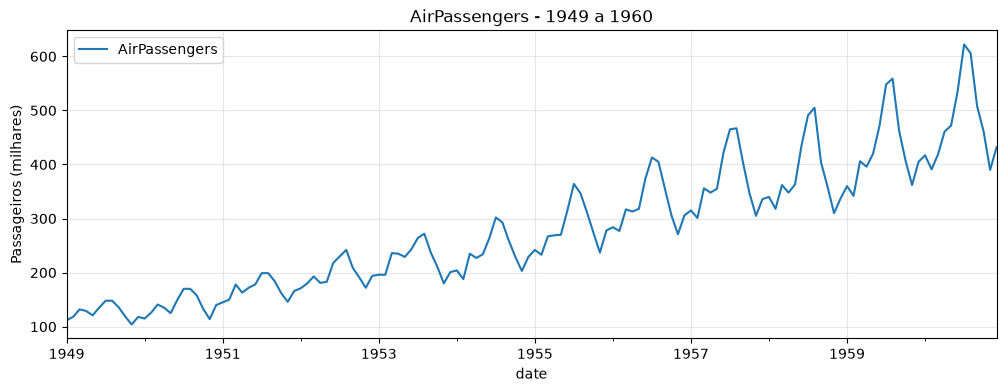

In [6]:
df_air.plot(figsize=(12, 4), title='AirPassengers - 1949 a 1960')
plt.ylabel('Passageiros (milhares)')
plt.grid(alpha=0.3)
plt.show()

Estudando as métricas, importando do SKlearn

In [ ]:
def mse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def mape(y_true, y_pred):
    # sklearn retorna proporção (0.1 = 10%), multiplico por 100 para percentual
    return mean_absolute_percentage_error(y_true, y_pred) * 100

Métricas gerais - implementação manual

In [ ]:
def pocid(y_true, y_pred):
    # POCID: mede se o modelo acerta a direção do movimento
    # compara a variação real com a variação prevista
    y_true = np.asanyarray(y_true)
    y_pred = np.asanyarray(y_pred)

    # diferenças entre pontos consecutivos
    dif_real = np.diff(y_true)
    dif_pred = np.diff(y_pred)

    # produto > 0 significa que ambos foram na mesma direção
    acertos = (dif_real * dif_pred) > 0

    return 100 * np.mean(acertos)


def arv(y_true, y_pred):
    # ARV: compara erro do modelo com erro de prever a média
    # ARV < 1 -> modelo melhor que a média
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    numerador = np.sum((y_true - y_pred) ** 2)
    denominador = np.sum((y_true - np.mean(y_true)) ** 2)

    return numerador / denominador


def u_theil(y_true, y_pred):
    # U de Theil: compara modelo com naive (y_t = y_{t-1})
    # U < 1 -> modelo melhor que naive
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # erro do modelo entre t=1 e t=n
    numerador = np.sum((y_true[1:] - y_pred[1:]) ** 2)
    # erro do naive: prever y_{t-1} como sendo y_t
    denominador = np.sum((y_true[1:] - y_true[:-1]) ** 2)

    return np.sqrt(numerador / denominador)


# ---------------------- Função Consolidada -------------------------------------

def gerar_metricas(y_true, y_pred):
    return {
        'MSE': mse(y_true, y_pred),
        'RMSE': rmse(y_true, y_pred),
        'MAE': mae(y_true, y_pred),
        'MAPE': mape(y_true, y_pred),
        'POCID': pocid(y_true, y_pred),
        'ARV': arv(y_true, y_pred),
        'U-Theil': u_theil(y_true, y_pred)
    }